# VQ-VAE (Vector Quantized Variational Autoencoder) for Cassini CDA Mass Spectra

This notebook implements a **VQ-VAE (Vector Quantized Variational Autoencoder)** to analyze mass spectra from the Cassini Cosmic Dust Analyzer (CDA).

### Why VQ-VAE?
Unlike standard VAEs that use continuous latent distributions, VQ-VAE uses **discrete latent codes** from a learned codebook. This has several advantages:

1. **Discrete Latent Space**: Each spectrum is represented by a sequence of discrete codes from a learned codebook
2. **Better Interpretability**: Discrete codes can represent distinct chemical signatures or spectral patterns
3. **Compression**: Learns a compact vocabulary of spectral features that can be combined
4. **No Posterior Collapse**: Avoids the common VAE problem where the decoder ignores the latent code

### Architecture Highlights:
- **CNN Encoder**: Extracts continuous features from input spectra
- **Vector Quantization**: Maps continuous features to nearest discrete codes in learned codebook
- **Straight-Through Estimator**: Allows gradients to flow during backpropagation
- **CNN Decoder**: Reconstructs spectra from quantized codes
- **Triple Loss**: Reconstruction + Codebook + Commitment losses

### Pipeline Steps:
1. **Data Loading**: Load Parquet files containing the spectra
2. **Preprocessing**: Savitzky-Golay filtering → log transformation → normalization
3. **Model Architecture**: VQ-VAE with 128-dim embeddings and 512 codebook entries
4. **Training**: Minimize reconstruction + vector quantization losses
5. **Evaluation**: Ground truth metrics (Silhouette, Linear Probe, Reconstruction Error)

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN, KMeans
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Configuration
Input_Length = 1000  # Number of bins to resample spectra to
Batch_Size = 128
Learning_Rate = 1e-3
Epochs = 20
Embedding_Dim = 128  # Dimension of each codebook vector
Num_Embeddings = 512  # Number of vectors in the codebook
Commitment_Cost = 0.25  # Weight for commitment loss (encourages encoder to commit to codes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### 1. Data Loading
We load the data from a Parquet file. This efficient columnar format allows us to handle large datasets of spectra quickly. We also filter or crop the data to ensure we are only training on valid signals.

### 1.1 Class Analysis
Before training, it is crucial to understand the class imbalance. Real-world space data is dominated by "Noise" or empty impacts. Knowing the distribution helps us interpret why the model might cluster certain things together (e.g., if 90% of data is noise, the model will prioritize learning the shape of noise).

In [2]:
# 1. Load Data
# Adjust the filename as needed based on which file you want to train on
file_path = 'cda_qm_spectra_pre2008277_train_lvl2.parquet'

try:
    df = pd.read_parquet(file_path)
    print(f"Loaded data shape: {df.shape}")
    print(df.head())
    
    # Extract spectral data
    # Based on the output, the column is named 'spectrum'
    if 'spectrum' in df.columns:
        print("Found 'spectrum' column.")
        # Ensure it's a stack of numpy arrays
        spectra_raw = np.stack(df['spectrum'].values)
    else:
        raise ValueError(f"Column 'spectrum' not found. Available columns: {df.columns}")

except Exception as e:
    print(f"Error loading data: {e}")
    raise e

Loaded data shape: (19820, 6)
           sclk   f_desc  event_id  \
0  1.477582e+09  6405615      4035   
1  1.477619e+09  6405615      6860   
2  1.477626e+09  6405615     10363   
3  1.477630e+09  6405615     12290   
4  1.477666e+09  6405615     16489   

                                            spectrum       qi_ampl  class  
0  [-6.986339e-07, 0.0, 0.0, -8.7329244e-07, 5.23...  5.004700e-14  Noise  
1  [-1.7465848e-07, -8.7329244e-07, -1.7465848e-0...  4.182420e-14  3-Car  
2  [-1.7465848e-07, -1.7465848e-07, -1.7465848e-0...  1.700580e-14  3-Car  
3  [-3.4931696e-07, -3.4931696e-07, -3.4931696e-0...  1.312510e-14  3-KNa  
4  [-6.986339e-07, 0.0, -3.4931696e-07, -5.239755...  4.949150e-12  Noise  
Found 'spectrum' column.


Class distribution:
class
Noise    12077
1         4491
2         1015
3          909
?          553
4          263
5          186
3-Car       89
3-Cl        47
3-OH        47
3-KNa       41
5-Na        41
3-P         34
3-K         22
2-X          3
X            2
Name: count, dtype: int64

Total number of classes: 16


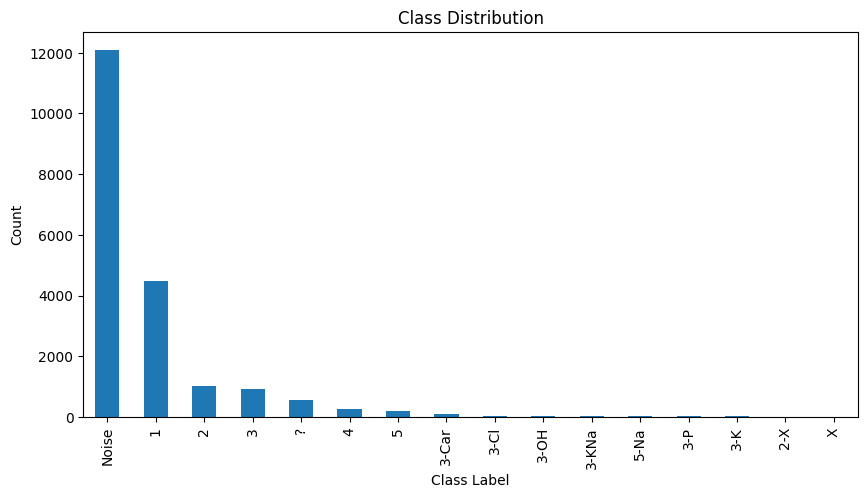

In [3]:
# 1.1 Analyze Classes
if 'class' in df.columns:
    print("Class distribution:")
    class_counts = df['class'].value_counts()
    print(class_counts)
    print(f"\nTotal number of classes: {len(class_counts)}")
    
    # Optional: Plot class distribution
    plt.figure(figsize=(10, 5))
    class_counts.plot(kind='bar')
    plt.title("Class Distribution")
    plt.ylabel("Count")
    plt.xlabel("Class Label")
    plt.show()
else:
    print("Column 'class' not found in dataframe.")

### 2. Preprocessing
We define a function to normalize and reshape the spectra.
*   **Target Length:** 1000 bins. This reduces the input dimensionality while preserving the resolution needed to distinguish mass lines.
*   **Denoising:** Apply Savitzky-Golay filter to smooth out high-frequency noise while preserving peak shapes. This is crucial for mass spectra where sharp peaks contain the chemical information.
*   **Log1p:** $\log(1+x)$ is used to squash the counts. Without this, a single giant peak (e.g., Amplitude 10,000) would render a small but chemically significant peak (Amplitude 10) invisible to the network (it would look like 0.001 after normalization).
*   **Normalization:** Scale to 0-1 range for stable neural network training.

Preprocessing data...
Processed Data Shape: (19820, 1000)
DataLoader created.
PREPROCESSING VISUALIZATION
  Key transformations:
    1. Crop/Pad → Fixed 1000-bin length
    2. Savitzky-Golay → Noise reduction while preserving peaks
    3. Log1p → Compress dynamic range (handle large/small peaks)
    4. Normalization → Scale to [0,1] for stable training



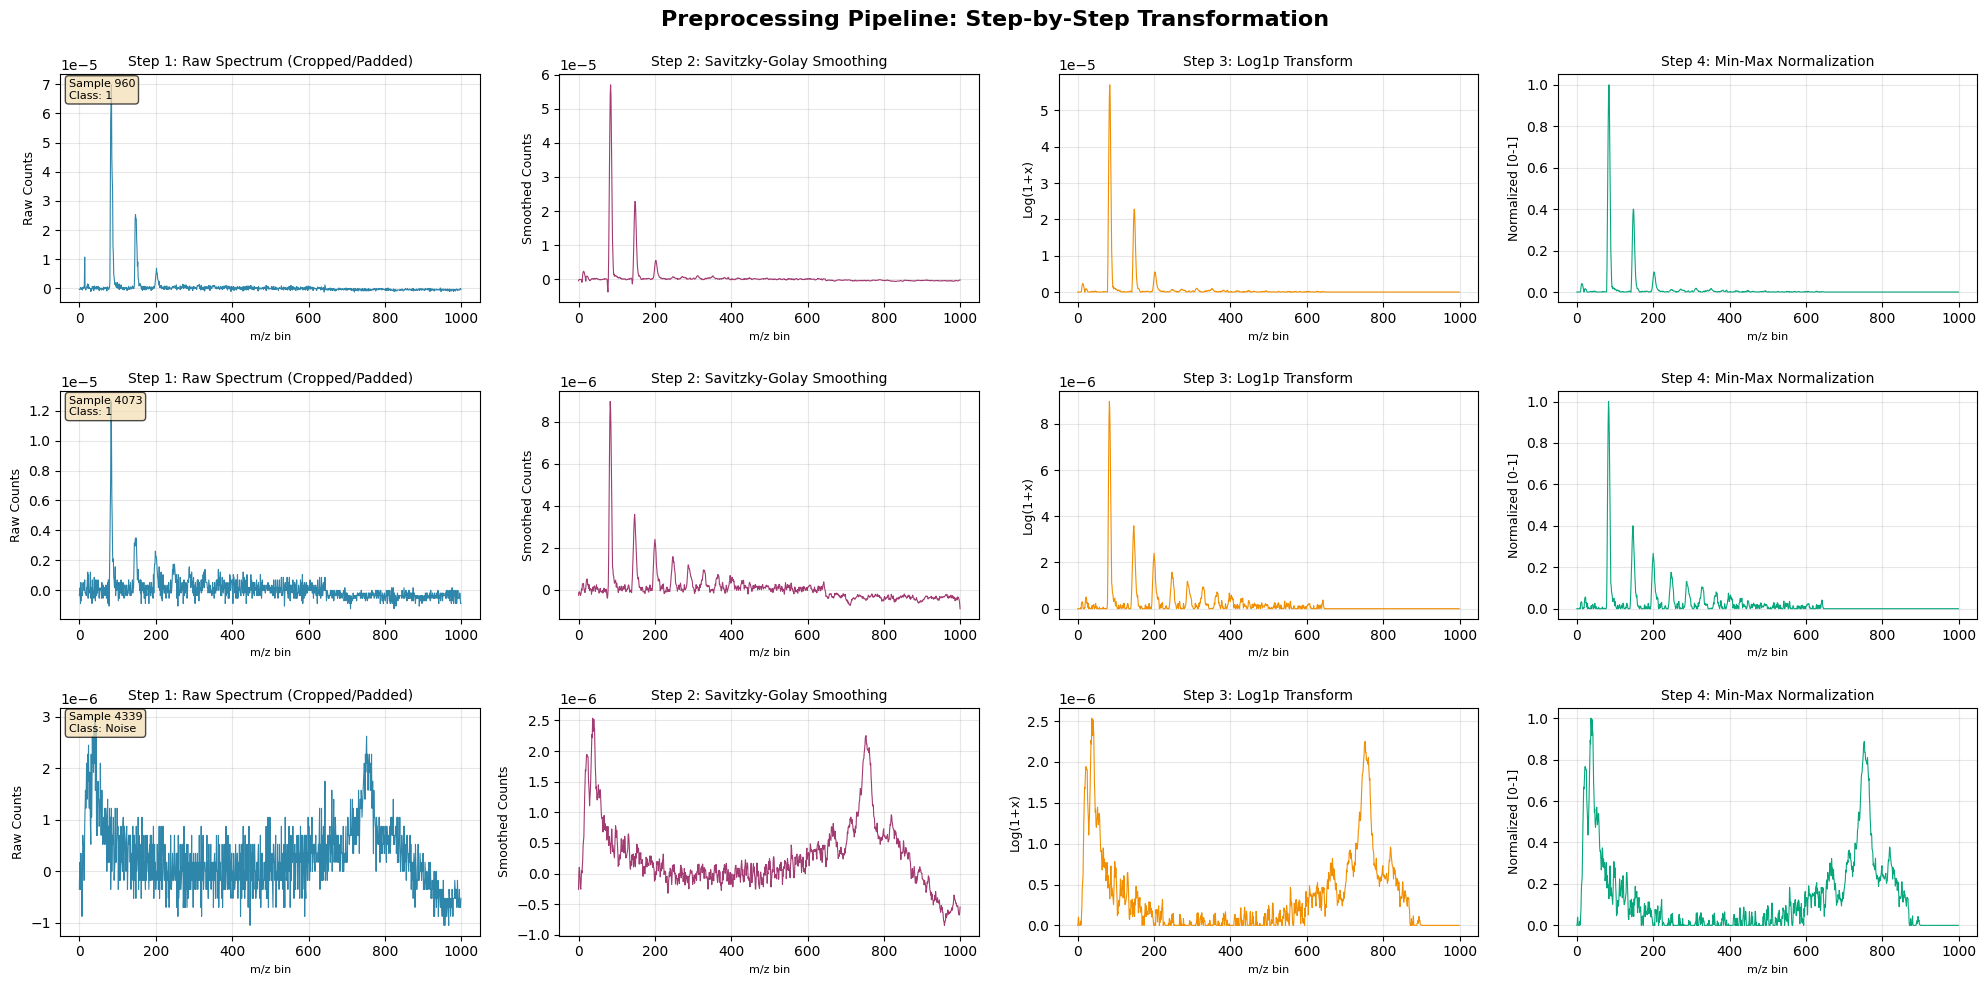


✓ Preprocessing visualization complete


In [4]:
# 2. Preprocessing Function
def preprocess_spectra(spectra, target_length=1000):
    processed = []
    
    for spec in spectra:
        # A. Handling varying lengths (if raw data is list of arrays)
        # Resize or pad/crop to target_length
        if len(spec) >= target_length:
            s = spec[:target_length]
        else:
            s = np.pad(spec, (0, target_length - len(spec)), 'constant')
        
        # B. Denoising with Savitzky-Golay filter
        # This smooths high-frequency noise while preserving peak shapes
        # window_length must be odd and less than array length
        window_length = min(11, len(s) if len(s) % 2 == 1 else len(s) - 1)
        if window_length >= 5:  # Only apply if window is large enough
            s = savgol_filter(s, window_length=window_length, polyorder=3)
        
        # C. Log Transformation (Compress dynamic range)
        # Adding a small epsilon or 1 to avoid log(0) or log(negative) issues if any
        # Assuming minimal value is 0 or -small noise
        s = np.log1p(np.maximum(s, 0))
        
        # D. Max Normalization (Scale to 0-1 range)
        max_val = np.max(s)
        if max_val > 0:
            s = s / max_val
            
        processed.append(s)
        
    return np.array(processed, dtype=np.float32)

# Apply preprocessing
print("Preprocessing data...")
X_train = preprocess_spectra(spectra_raw, target_length=Input_Length)

print(f"Processed Data Shape: {X_train.shape}")

# Convert to PyTorch Tensor
# Add channel dimension: (N, Channels, Length) -> (N, 1, 1000)
dataset = TensorDataset(torch.from_numpy(X_train).unsqueeze(1)) 
loader = DataLoader(dataset, batch_size=Batch_Size, shuffle=True)
print("DataLoader created.")

# Visualize preprocessing effects
print("="*70)
print("PREPROCESSING VISUALIZATION")
print("="*70)
print("  Key transformations:")
print("    1. Crop/Pad → Fixed 1000-bin length")
print("    2. Savitzky-Golay → Noise reduction while preserving peaks")
print("    3. Log1p → Compress dynamic range (handle large/small peaks)")
print("    4. Normalization → Scale to [0,1] for stable training")
print("\n" + "="*70)

# Select 3 random samples to visualize
np.random.seed(42)
sample_indices = np.random.choice(len(spectra_raw), size=3, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(20, 10))
fig.suptitle('Preprocessing Pipeline: Step-by-Step Transformation', fontsize=16, fontweight='bold')

for ax in axes.flat:
    ax.set_xlabel('m/z bin', fontsize=8)

for i, idx in enumerate(sample_indices):
    spec = spectra_raw[idx]
    
    # Add sample info
    class_label = df.iloc[idx]['class'] if 'class' in df.columns else 'Unknown'
    
    # Step 1: Raw spectrum
    if len(spec) >= Input_Length:
        s1 = spec[:Input_Length]
    else:
        s1 = np.pad(spec, (0, Input_Length - len(spec)), 'constant')
    
    axes[i, 0].plot(s1, linewidth=0.8, color='#2E86AB')
    axes[i, 0].set_title('Step 1: Raw Spectrum (Cropped/Padded)', fontsize=10)
    axes[i, 0].set_ylabel('Raw Counts', fontsize=9)
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].text(0.02, 0.98, f'Sample {idx}\nClass: {class_label}', 
                    transform=axes[i, 0].transAxes, fontsize=8,
                    verticalalignment='top', bbox=dict(boxstyle='round', 
                    facecolor='wheat', alpha=0.7))
    
    # Step 2: After Savitzky-Golay filtering
    window_length = min(11, len(s1) if len(s1) % 2 == 1 else len(s1) - 1)
    if window_length >= 5:
        s2 = savgol_filter(s1, window_length=window_length, polyorder=3)
    else:
        s2 = s1.copy()
    
    axes[i, 1].plot(s2, linewidth=0.8, color='#A23B72')
    axes[i, 1].set_title('Step 2: Savitzky-Golay Smoothing', fontsize=10)
    axes[i, 1].set_ylabel('Smoothed Counts', fontsize=9)
    axes[i, 1].grid(True, alpha=0.3)
    
    # Step 3: After log transformation
    s3 = np.log1p(np.maximum(s2, 0))
    
    axes[i, 2].plot(s3, linewidth=0.8, color='#F18F01')
    axes[i, 2].set_title('Step 3: Log1p Transform', fontsize=10)
    axes[i, 2].set_ylabel('Log(1+x)', fontsize=9)
    axes[i, 2].grid(True, alpha=0.3)
    
    # Step 4: After normalization
    max_val = np.max(s3)
    if max_val > 0:
        s4 = s3 / max_val
    else:
        s4 = s3.copy()
    
    axes[i, 3].plot(s4, linewidth=0.8, color='#06A77D')
    axes[i, 3].set_title('Step 4: Min-Max Normalization', fontsize=10)
    axes[i, 3].set_ylabel('Normalized [0-1]', fontsize=9)
    axes[i, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Preprocessing visualization complete")

### 3. VQ-VAE (Vector Quantized Variational Autoencoder) Architecture
We construct a **Discrete Latent CNN Encoder-Decoder** network with vector quantization.

**Key Components:**
*   **CNN Encoder**: Extracts continuous feature representation from input spectra

*   **Vector Quantizer**: 
    - Maintains a learnable **codebook** of K embedding vectors (e.g., 512 codes of 128 dims each)
    - Maps each continuous feature to its **nearest neighbor** in the codebook
    - Uses **straight-through estimator** to copy gradients during backpropagation

*   **CNN Decoder**: Reconstructs spectra from quantized discrete codes

*   **Triple Loss Function**:
    - **Reconstruction Loss**: MSE between input and output

    - **Codebook Loss**: Encourages codebook vectors to move towards encoder outputs**Advantage**: Discrete latent codes avoid posterior collapse and create interpretable spectral vocabularies.

    - **Commitment Loss**: Encourages encoder outputs to commit to specific codes

In [5]:
# 3. VQ-VAE (Vector Quantized Variational Autoencoder)
class VectorQuantizer(nn.Module):
    """
    Vector Quantization layer that maps continuous encoder outputs to discrete codebook entries.
    Uses straight-through estimator for backpropagation.
    """
    def __init__(self, num_embeddings, embedding_dim, commitment_cost):
        super(VectorQuantizer, self).__init__()
        
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.commitment_cost = commitment_cost
        
        # Learnable codebook: (num_embeddings, embedding_dim)
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1/num_embeddings, 1/num_embeddings)
    
    def forward(self, z):
        """
        Args:
            z: Encoder output, shape (B, embedding_dim, L)
        Returns:
            quantized: Quantized output (same shape as z)
            vq_loss: Vector quantization loss
            perplexity: Codebook usage metric
        """
        # Reshape: (B, embedding_dim, L) -> (B, L, embedding_dim)
        z = z.permute(0, 2, 1).contiguous()
        z_flattened = z.view(-1, self.embedding_dim)
        
        # Calculate distances to codebook vectors: ||z - e||^2
        distances = (torch.sum(z_flattened**2, dim=1, keepdim=True) 
                    + torch.sum(self.embedding.weight**2, dim=1)
                    - 2 * torch.matmul(z_flattened, self.embedding.weight.t()))
        
        # Find nearest codebook entry
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(encoding_indices.shape[0], self.num_embeddings, device=z.device)
        encodings.scatter_(1, encoding_indices, 1)
        
        # Quantize
        quantized = torch.matmul(encodings, self.embedding.weight)
        quantized = quantized.view_as(z)
        
        # Codebook loss: moves codebook vectors towards encoder outputs
        e_latent_loss = torch.mean((quantized.detach() - z)**2)
        
        # Commitment loss: encourages encoder to commit to codebook entries
        q_latent_loss = torch.mean((quantized - z.detach())**2)
        
        # Combined VQ loss
        vq_loss = e_latent_loss + self.commitment_cost * q_latent_loss
        
        # Straight-through estimator: copy gradients from decoder to encoder
        quantized = z + (quantized - z).detach()
        
        # Calculate perplexity (measure of codebook usage)
        avg_probs = torch.mean(encodings, dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
        
        # Reshape back: (B, L, embedding_dim) -> (B, embedding_dim, L)
        quantized = quantized.permute(0, 2, 1).contiguous()
        
        return quantized, vq_loss, perplexity


class VQVAE(nn.Module):
    def __init__(self, input_len=1000, embedding_dim=128, num_embeddings=512, commitment_cost=0.25):
        """
        VQ-VAE with discrete latent space.
        
        Args:
            input_len: Length of input spectrum (default: 1000)
            embedding_dim: Dimension of each codebook vector (default: 128)
            num_embeddings: Number of codebook entries (default: 512)
            commitment_cost: Weight for commitment loss (default: 0.25)
        """
        super(VQVAE, self).__init__()
        
        self.embedding_dim = embedding_dim
        
        # Encoder: CNN feature extraction
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, stride=2, padding=2),   # 1000 → 500
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),  # 500 → 250
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2), # 250 → 125
            nn.ReLU(),
            nn.BatchNorm1d(128),
        )
        
        # Vector Quantizer
        self.vq = VectorQuantizer(num_embeddings, embedding_dim, commitment_cost)
        
        # Decoder: CNN reconstruction
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),  # 125 → 250
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.ConvTranspose1d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=1),   # 250 → 500
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.ConvTranspose1d(32, 1, kernel_size=5, stride=2, padding=2, output_padding=1),    # 500 → 1000
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encode
        z = self.encoder(x)
        
        # Vector quantization
        quantized, vq_loss, perplexity = self.vq(z)
        
        # Decode
        reconstructed = self.decoder(quantized)
        
        return reconstructed, vq_loss, perplexity, quantized


print("="*70)
print("VQ-VAE (VECTOR QUANTIZED VARIATIONAL AUTOENCODER) ARCHITECTURE")
print("="*70)

# Initialize VQ-VAE model
model = VQVAE(
    input_len=Input_Length, 
    embedding_dim=Embedding_Dim, 
    num_embeddings=Num_Embeddings,
    commitment_cost=Commitment_Cost
).to(device)

print(model)
print("="*70)
print(f"Embedding Dimensions: {Embedding_Dim}")
print(f"Codebook Size: {Num_Embeddings} discrete codes")
print(f"Commitment Cost: {Commitment_Cost}")
print(f"Total Codebook Parameters: {Num_Embeddings * Embedding_Dim:,}")
print("="*70)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
codebook_params = model.vq.embedding.weight.numel()
encoder_decoder_params = total_params - codebook_params
print(f"\nModel Parameters:")
print(f"  Total Parameters: {total_params:,}")
print(f"  Trainable Parameters: {trainable_params:,}")
print(f"  Encoder + Decoder: {encoder_decoder_params:,}")
print(f"  Codebook (VQ): {codebook_params:,}")
print("="*70)

VQ-VAE (VECTOR QUANTIZED VARIATIONAL AUTOENCODER) ARCHITECTURE
VQVAE(
  (encoder): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(2,), padding=(2,))
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (4): ReLU()
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv1d(64, 128, kernel_size=(5,), stride=(2,), padding=(2,))
    (7): ReLU()
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (vq): VectorQuantizer(
    (embedding): Embedding(512, 128)
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(128, 64, kernel_size=(5,), stride=(2,), padding=(2,), output_padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ConvTranspose1d(64, 32, kernel_size=(5,), stride=(2,), padding=(2,), outp

### 4. Training the VQ-VAE

Train the Vector Quantized VAE with Adam optimizer. The loss combines:

- **Reconstruction Loss**: MSE between input and output- **Perplexity**: Monitors codebook usage (higher = more codes used)
- **Vector Quantization Loss**: Codebook + Commitment losses (computed by VectorQuantizer)

In [6]:
# # 4. Training Loop with VQ-VAE Loss
# optimizer = optim.Adam(model.parameters(), lr=Learning_Rate)

# print("="*70)
# print(f"Training VQ-VAE (Embedding Dim: {Embedding_Dim}, Codebook: {Num_Embeddings})")
# print(f"Commitment Cost: {Commitment_Cost}")
# print("="*70)

# for epoch in range(Epochs):
#     model.train()
#     total_loss = 0
#     total_recon = 0
#     total_vq = 0
#     total_perplexity = 0
    
#     for batch in loader:
#         img = batch[0].to(device)
        
#         optimizer.zero_grad()
        
#         # Forward pass
#         recon, vq_loss, perplexity, quantized = model(img)
        
#         # Reconstruction loss (MSE)
#         recon_loss = nn.functional.mse_loss(recon, img)
        
#         # Total loss: Reconstruction + Vector Quantization
#         loss = recon_loss + vq_loss
        
#         # Backward pass
#         loss.backward()
#         optimizer.step()
        
#         total_loss += loss.item()
#         total_recon += recon_loss.item()
#         total_vq += vq_loss.item()
#         total_perplexity += perplexity.item()
    
#     # Average losses
#     avg_loss = total_loss / len(loader)
#     avg_recon = total_recon / len(loader)
#     avg_vq = total_vq / len(loader)
#     avg_perplexity = total_perplexity / len(loader)
    
#     print(f"Epoch {epoch+1}/{Epochs}, Total Loss: {avg_loss:.6f}, Recon: {avg_recon:.6f}, VQ: {avg_vq:.6f}, Perplexity: {avg_perplexity:.1f}")

# print("\n✓ Training complete!")

# # Save the VQ-VAE model
# model_save_path = f'vqvae_embed{Embedding_Dim}_codebook{Num_Embeddings}.pth'
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'embedding_dim': Embedding_Dim,
#     'num_embeddings': Num_Embeddings,
#     'input_length': Input_Length,
#     'epochs': Epochs,
#     'commitment_cost': Commitment_Cost,
# }, model_save_path)

# print(f"✓ Model saved to {model_save_path}")

In [7]:
# Load previously trained VQ-VAE model
import os

model_save_path_vqvae = f'vqvae_embed{Embedding_Dim}_codebook{Num_Embeddings}.pth'

if os.path.exists(model_save_path_vqvae):
    # Recreate model architecture
    model_loaded = VQVAE(
        input_len=Input_Length, 
        embedding_dim=Embedding_Dim, 
        num_embeddings=Num_Embeddings,
        commitment_cost=Commitment_Cost
    ).to(device)
    
    # Load weights
    checkpoint = torch.load(model_save_path_vqvae, map_location=device)
    model_loaded.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"✓ VQ-VAE model loaded from {model_save_path_vqvae}")
    print(f"  Embedding Dimensions: {checkpoint['embedding_dim']}")
    print(f"  Codebook Size: {checkpoint['num_embeddings']}")
    print(f"  Commitment Cost: {checkpoint['commitment_cost']}")
    print(f"  Trained for: {checkpoint['epochs']} epochs")
    
    # Use this model for evaluation
    model = model_loaded
    print(f"\n⚠️  'model' variable now points to loaded VQ-VAE")
else:
    print(f"✗ Model file {model_save_path_vqvae} not found.")
    print(f"  Please train the VQ-VAE model first using the training cell above")

✓ VQ-VAE model loaded from vqvae_embed128_codebook512.pth
  Embedding Dimensions: 128
  Codebook Size: 512
  Commitment Cost: 0.25
  Trained for: 20 epochs

⚠️  'model' variable now points to loaded VQ-VAE


### 5. Latent Space Extraction & Ground Truth Evaluation
Once trained, we use the **VQ-VAE Encoder + Quantizer** to extract the "Latent Features" for every spectrum.
*   **Discrete Representation**: Each spectrum is represented by quantized codes from the learned codebook
*   **Dimensionality Reduction**: The spatial dimension is reduced (1000 → 125 time steps), and each time step is a 128-dim discrete code
*   **For Evaluation**: We use the quantized continuous representation (128-dim embeddings × 125 positions) flattened as features
*   **Ground Truth Evaluation**: Instead of unsupervised clustering, we evaluate how well the latent space naturally separates known chemical classes (Na, Ca, Sulfur, Noise, etc.) using:
    1. **Silhouette Score**: Measures natural separation of ground truth classes in latent space
    2. **Linear Probe**: Tests if a simple linear classifier can distinguish chemical species from latent features
    3. **Reconstruction Error**: Quantifies how well different chemical classes are reconstructed

In [9]:
# 5. Extract Latent Space & Calculate Reconstruction Error (VQ-VAE)
model.eval()
with torch.no_grad():
   # Pass all data through model in original order
   data_tensor = torch.from_numpy(X_train).unsqueeze(1).to(device)
   reconstructed, vq_loss, perplexity, quantized = model(data_tensor)
   
   # For VQ-VAE evaluation, use quantized vectors as latent representation
   # Shape: (N, embedding_dim, L) -> flatten to (N, embedding_dim * L)
   latent_flat = quantized.cpu().numpy().reshape(len(X_train), -1)
   
   # Calculate Reconstruction Error per sample
   # MSE between input (data_tensor) and output (reconstructed)
   # Shape: (N, 1, L) -> (N,)
   reconstruction_error = torch.mean((data_tensor - reconstructed) ** 2, dim=[1, 2]).cpu().numpy()

# Add metrics to dataframe
df['recon_error'] = reconstruction_error

print(f"Latent space shape: {latent_flat.shape}")
print(f"  (Flattened from {Embedding_Dim} dims × 125 positions)")
print(f"Mean reconstruction error: {reconstruction_error.mean():.6f}")

print(f"Std reconstruction error: {reconstruction_error.std():.6f}")
print(f"Final codebook perplexity: {perplexity.item():.1f} / {Num_Embeddings}")

Latent space shape: (19820, 16000)
  (Flattened from 128 dims × 125 positions)
Mean reconstruction error: 0.007175
Std reconstruction error: 0.008446
Final codebook perplexity: 7.7 / 512


In [ ]:
# 5.1 Ground Truth Evaluation Metrics
from sklearn.metrics import silhouette_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress all warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

print("="*70)
print("GROUND TRUTH EVALUATION: Latent Space Quality")
print("="*70)

# Prepare ground truth labels
if 'class' not in df.columns:
    raise ValueError("Ground truth 'class' column not found in dataframe!")

ground_truth_labels = df['class'].values
le = LabelEncoder()
y_encoded = le.fit_transform(ground_truth_labels)

# Filter out classes with too few samples (need at least 5 for stratified 5-fold CV)
class_counts = pd.Series(ground_truth_labels).value_counts()
valid_classes = class_counts[class_counts >= 5].index  # Increased threshold for CV stability
valid_mask = df['class'].isin(valid_classes)

latent_valid = latent_flat[valid_mask]
y_valid = y_encoded[valid_mask]
ground_truth_valid = ground_truth_labels[valid_mask]

print(f"\nDataset: {len(latent_flat)} total samples")
print(f"Valid samples (classes with ≥5 samples): {len(latent_valid)}")
print(f"Number of unique classes: {len(np.unique(y_valid))}")
print(f"\nClass distribution:")
print(pd.Series(ground_truth_valid).value_counts().sort_index())

# ============================================================================
# METRIC 1: Latent Silhouette Score (Ground Truth Classes)
# ============================================================================
print("\n" + "="*70)
print("METRIC 1: Latent Silhouette Score")
print("="*70)
print("Measures how well ground truth classes are naturally separated in latent space")
print("Range: [-1, 1] | Higher is better | >0.5 = good separation\n")

if len(np.unique(y_valid)) > 1:
    # Normalize latent space for better distance metrics
    scaler = StandardScaler()
    latent_normalized = scaler.fit_transform(latent_valid)
    
    latent_silhouette = silhouette_score(latent_normalized, y_valid, metric='euclidean')
    
    print(f"✓ Latent Silhouette Score: {latent_silhouette:.4f}")
else:
    latent_silhouette = 0.0
    latent_normalized = scaler.fit_transform(latent_valid)
    print("✗ Cannot compute silhouette score (need at least 2 classes)")

# ============================================================================
# METRIC 2: Linear Probe Classification (3-Fold Cross-Validation)
# ============================================================================
print("\n" + "="*70)
print("METRIC 2: Linear Probe Classification")
print("="*70)
print("Tests if latent features are linearly separable by chemical class")
print("Uses Logistic Regression with 3-fold stratified cross-validation\n")

# Reduce latent dimensionality using PCA for faster training
from sklearn.decomposition import PCA

# Use PCA to reduce to 256 dimensions (or less if original is smaller)
n_components = min(256, latent_normalized.shape[1], len(latent_valid) - 1)
print(f"  Reducing dimensionality: {latent_normalized.shape[1]} → {n_components} dims using PCA...")
pca = PCA(n_components=n_components, random_state=42)
latent_reduced = pca.fit_transform(latent_normalized)
print(f"  Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Use simpler LogisticRegression without deprecated parameters
linear_probe = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=1,  # Single job to avoid memory issues
    solver='saga',  # Faster solver for large datasets
    penalty='l2',
    C=1.0
)

# 3-fold stratified cross-validation (faster than 5-fold)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
print(f"  Running 3-fold cross-validation (this may take 1-2 minutes)...")

f1_scores = cross_val_score(
    linear_probe, 
    latent_reduced, 
    y_valid, 
    cv=cv, 
    scoring='f1_weighted',
    n_jobs=1  # Sequential to avoid memory issues
)

mean_f1 = f1_scores.mean()
std_f1 = f1_scores.std()

print(f"✓ Linear Probe F1-Score (weighted, 3-fold CV):")
print(f"  Mean: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"  Fold scores: {[f'{s:.4f}' for s in f1_scores]}")

# Train on full dataset for detailed report
print(f"  Training final model on full dataset...")
linear_probe.fit(latent_reduced, y_valid)
y_pred = linear_probe.predict(latent_reduced)
print(f"\n  Detailed Classification Report (Full Training Set):")
print(classification_report(ground_truth_valid, le.inverse_transform(y_pred), zero_division=0))

# ============================================================================
# METRIC 3: Reconstruction Error by Chemical Class
# ============================================================================
print("\n" + "="*70)
print("METRIC 3: Reconstruction Error by Chemical Class")
print("="*70)
print("Shows which chemical signatures are easier/harder to reconstruct\n")

recon_by_class = df.groupby('class')['recon_error'].agg(['mean', 'std', 'count'])
recon_by_class = recon_by_class.sort_values('mean', ascending=False)

print(recon_by_class.to_string())

# Identify easiest and hardest to reconstruct
easiest_class = recon_by_class['mean'].idxmin()
hardest_class = recon_by_class['mean'].idxmax()

print(f"\n✓ Easiest to reconstruct: {easiest_class} (error: {recon_by_class.loc[easiest_class, 'mean']:.6f})")
print(f"✗ Hardest to reconstruct: {hardest_class} (error: {recon_by_class.loc[hardest_class, 'mean']:.6f})")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("="*70)
print("SUMMARY: VQ-VAE (Vector Quantized VAE) Performance")
print("="*70)

summary_metrics = {
    'Model': 'VQ-VAE (Vector Quantized VAE)',
    'Latent Silhouette Score': f'{latent_silhouette:.4f}',
    'Linear Probe F1 (5-fold CV)': f'{mean_f1:.4f} ± {std_f1:.4f}',
    'Mean Reconstruction Error': f'{reconstruction_error.mean():.6f}',
    'Embedding Dimensions': Embedding_Dim,
    'Codebook Size': Num_Embeddings,
    'Commitment Cost': Commitment_Cost,
    'Flattened Latent Dims': latent_flat.shape[1]
}

for key, value in summary_metrics.items():
    print(f"{key:.<35} {value}")

    print("="*70)

GROUND TRUTH EVALUATION: Latent Space Quality

Dataset: 19820 total samples
Valid samples (classes with ≥5 samples): 19815
Number of unique classes: 14

Class distribution:
1         4491
2         1015
3          909
3-Car       89
3-Cl        47
3-K         22
3-KNa       41
3-OH        47
3-P         34
4          263
5          186
5-Na        41
?          553
Noise    12077
Name: count, dtype: int64

METRIC 1: Latent Silhouette Score
Measures how well ground truth classes are naturally separated in latent space
Range: [-1, 1] | Higher is better | >0.5 = good separation


Dataset: 19820 total samples
Valid samples (classes with ≥5 samples): 19815
Number of unique classes: 14

Class distribution:
1         4491
2         1015
3          909
3-Car       89
3-Cl        47
3-K         22
3-KNa       41
3-OH        47
3-P         34
4          263
5          186
5-Na        41
?          553
Noise    12077
Name: count, dtype: int64

METRIC 1: Latent Silhouette Score
Measures how well g

### 5.1 Ground Truth Evaluation: Latent Space Quality

We evaluate how well the VQ-VAE's latent space naturally separates the known chemical classes **without** using any labels during training. This tests whether the model learned physically meaningful representations.

**Note for VQ-VAE**: We use the quantized continuous embeddings (flattened) as feature vectors. These discrete codes from the learned codebook should ideally capture distinct chemical signatures.

**Three Key Metrics:**
1. **Latent Silhouette Score**: Measures how well ground truth classes are separated in latent space (higher = better natural clustering)
2. **Linear Probe F1-Score**: Tests if a simple linear classifier can distinguish chemical species from latent features (5-fold CV)
3. **Reconstruction Error by Class**: Shows which chemical signatures are easier/harder for the VQ-VAE to reconstruct

### 5.2 Visualization: Latent Space Colored by Ground Truth

We use dimensionality reduction (t-SNE and UMAP) to visualize the latent space in 2D, colored by the **ground truth chemical classes**. This allows us to visually verify whether similar chemical species cluster together naturally.

In [11]:
# 5.2 Latent Space Visualization (t-SNE and UMAP)
from sklearn.manifold import TSNE
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder, StandardScaler


# Prepare normalized latent space for visualization
scaler_viz = StandardScaler()
latent_normalized_viz = scaler_viz.fit_transform(latent_flat)

# Create color map for all classes
unique_classes = df['class'].unique()
n_classes = len(unique_classes)
colors_map = cm.get_cmap('tab20', n_classes)
class_to_color = {cls: colors_map(i) for i, cls in enumerate(unique_classes)}
colors_by_class = [class_to_color[cls] for cls in df['class']]


/var/folders/62/j0rvb9vs6r75_3h8qzlh0j7m0000gp/T/ipykernel_53329/1542341552.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_map = cm.get_cmap('tab20', n_classes)


/var/folders/g5/rkylp13n0yz8q2ndgqgw9n59wq2btf/T/ipykernel_36375/3172392781.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_map = cm.get_cmap('tab20', n_classes)
/opt/anaconda3/envs/ml/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Computing dimensionality reductions for visualization...
  - Computing t-SNE (this may take 1-2 minutes)...
  ✓ t-SNE complete
  ⚠ UMAP not installed (pip install umap-learn). Skipping UMAP visualization.
  ✓ t-SNE complete
  ⚠ UMAP not installed (pip install umap-learn). Skipping UMAP visualization.


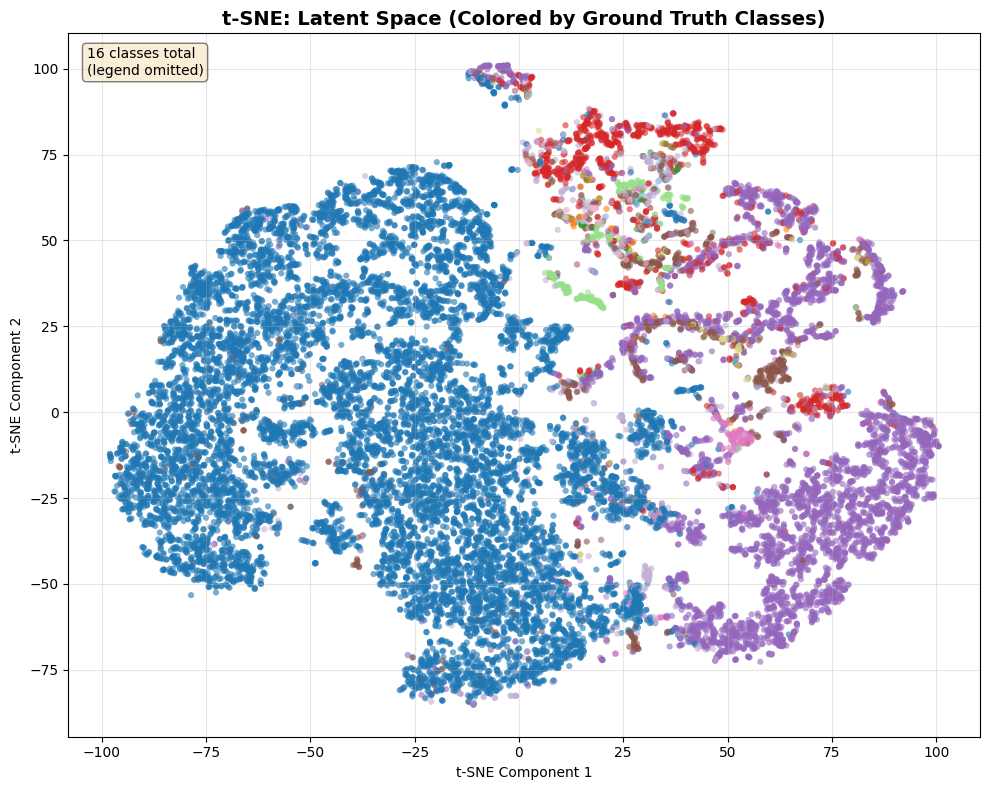


✓ Visualization complete. Latent dimensions: 10


In [ ]:

print("Computing dimensionality reductions for visualization...")

# ============================================================================
# t-SNE Embedding
# ============================================================================
print("  - Computing t-SNE (this may take 1-2 minutes)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)
tsne_embedding = tsne.fit_transform(latent_normalized_viz)
print("  ✓ t-SNE complete")

# ============================================================================
# UMAP Embedding (if available)
# ============================================================================
try:
    import umap
    print("  - Computing UMAP...")
    umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    umap_embedding = umap_reducer.fit_transform(latent_normalized_viz)
    print("  ✓ UMAP complete")
    has_umap = True
except ImportError:
    print("  ⚠ UMAP not installed (pip install umap-learn). Skipping UMAP visualization.")
    has_umap = False

# ============================================================================
# Plotting
# ============================================================================
n_plots = 2 if has_umap else 1
fig, axes = plt.subplots(1, n_plots, figsize=(10*n_plots, 8))
if n_plots == 1:
    axes = [axes]

# Plot 1: t-SNE colored by ground truth
ax = axes[0]
scatter = ax.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], 
                     c=colors_by_class, s=20, alpha=0.6, edgecolors='none')
ax.set_title('t-SNE: Latent Space (Colored by Ground Truth Classes)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.grid(True, alpha=0.3)

# Create legend (limit to reasonable number of classes)
if n_classes <= 15:
    patches = [mpatches.Patch(color=class_to_color[cls], label=cls) 
               for cls in unique_classes]
    ax.legend(handles=patches, loc='best', ncol=2 if n_classes > 8 else 1, 
              fontsize=8, framealpha=0.9)
else:
    ax.text(0.02, 0.98, f'{n_classes} classes total\n(legend omitted)', 
            transform=ax.transAxes, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: UMAP colored by ground truth (if available)
if has_umap:
    ax = axes[1]
    scatter = ax.scatter(umap_embedding[:, 0], umap_embedding[:, 1], 
                         c=colors_by_class, s=20, alpha=0.6, edgecolors='none')
    ax.set_title('UMAP: Latent Space (Colored by Ground Truth Classes)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('UMAP Component 1')
    ax.set_ylabel('UMAP Component 2')
    ax.grid(True, alpha=0.3)
    
    if n_classes <= 15:
        patches = [mpatches.Patch(color=class_to_color[cls], label=cls) 
                   for cls in unique_classes]
        ax.legend(handles=patches, loc='best', ncol=2 if n_classes > 8 else 1, 
                  fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization complete. Latent dimensions: {latent_flat.shape[1]}")

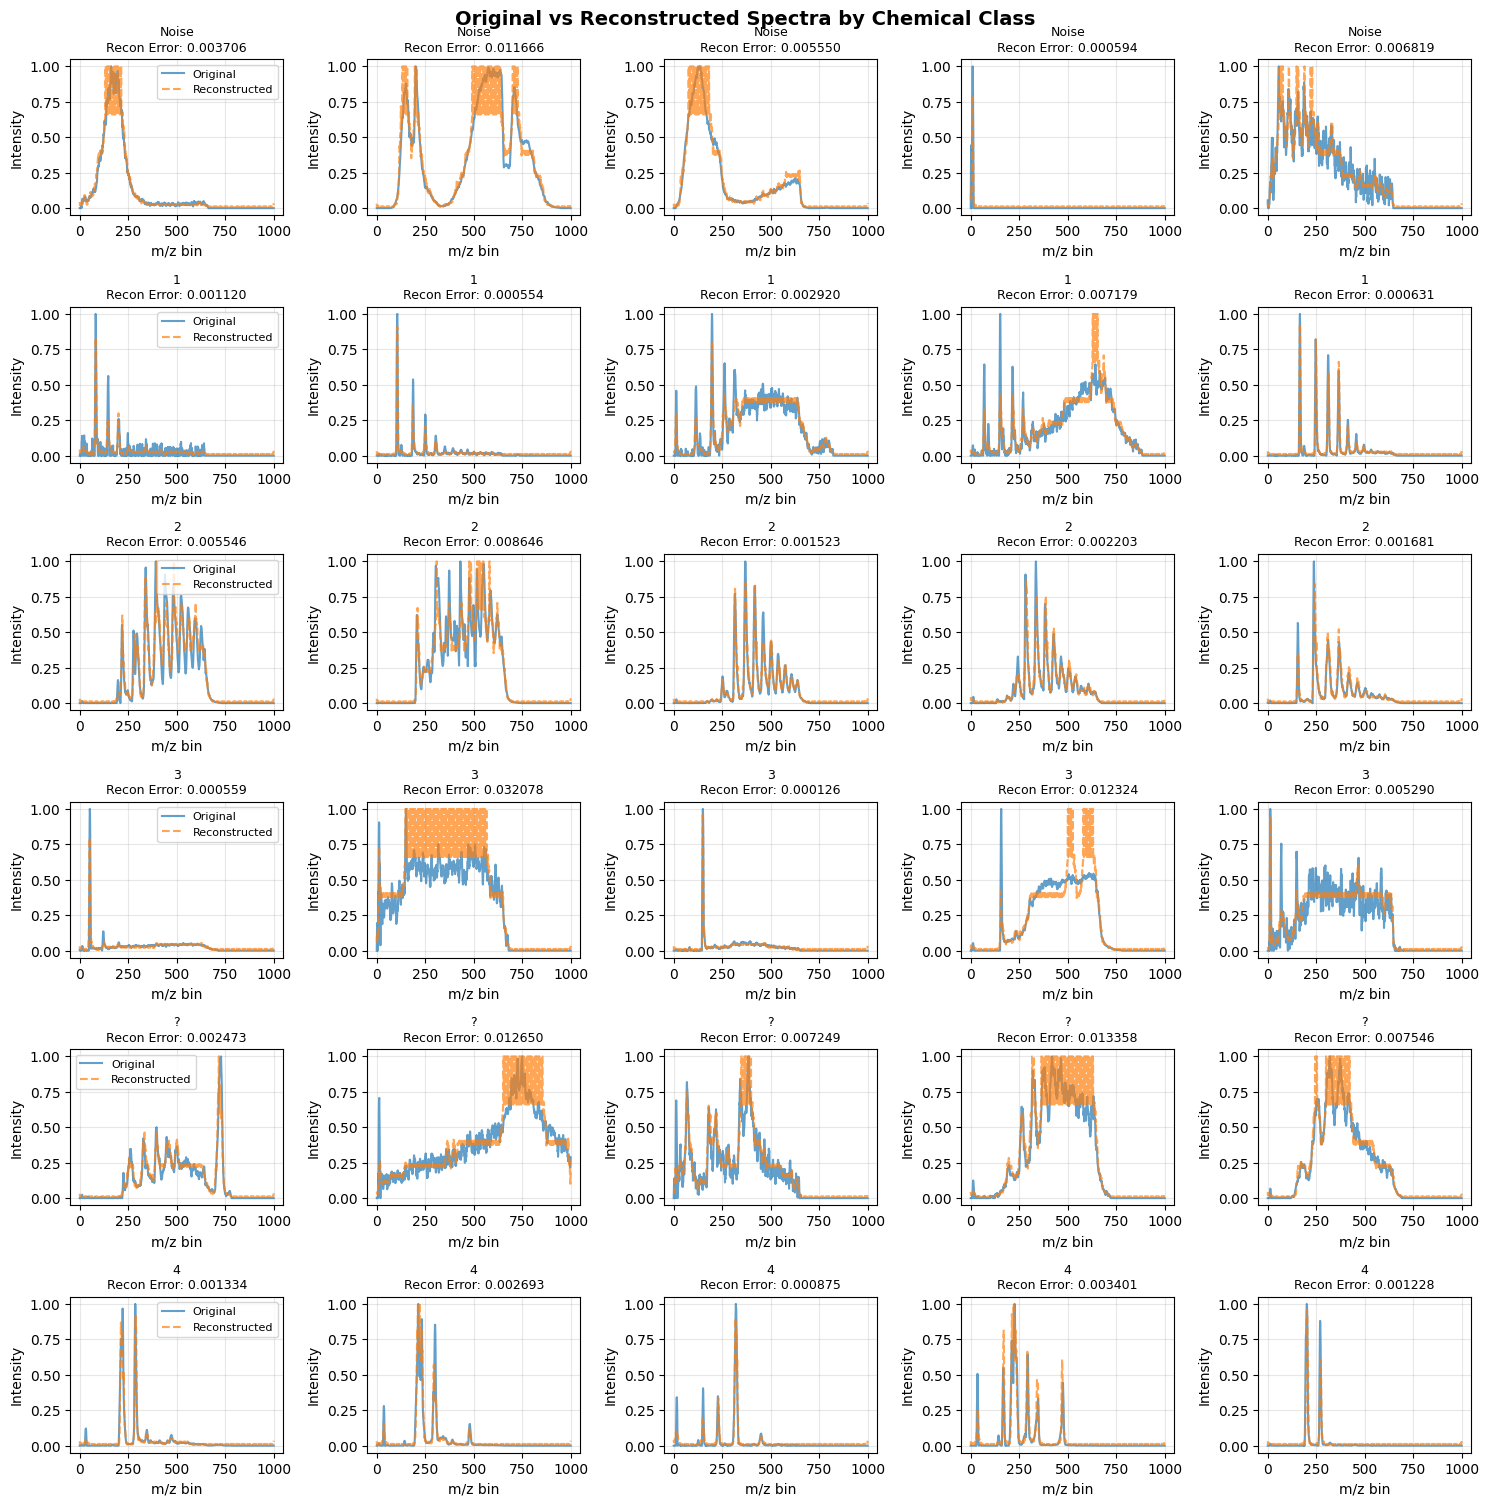

In [12]:
# 5.3 Example Reconstructions
# Visualize original vs reconstructed spectra for different chemical classes

n_examples = 5  # Number of examples per class to show
n_classes_to_show = min(6, len(unique_classes))  # Limit to 6 classes for readability

# Select classes with most samples
top_classes = df['class'].value_counts().head(n_classes_to_show).index

fig, axes = plt.subplots(n_classes_to_show, n_examples, figsize=(15, 2.5*n_classes_to_show))
if n_classes_to_show == 1:
    axes = axes.reshape(1, -1)

reconstructed_numpy = reconstructed.cpu().numpy()

for i, cls in enumerate(top_classes):
    class_indices = df[df['class'] == cls].index[:n_examples]
    
    for j, idx in enumerate(class_indices):
        ax = axes[i, j]
        
        # Original spectrum
        ax.plot(X_train[idx], label='Original', alpha=0.7, linewidth=1.5)
        # Reconstructed spectrum
        ax.plot(reconstructed_numpy[idx, 0, :], label='Reconstructed', 
                alpha=0.7, linewidth=1.5, linestyle='--')
        
        ax.set_title(f'{cls}\nRecon Error: {reconstruction_error[idx]:.6f}', fontsize=9)
        ax.set_xlabel('m/z bin')
        ax.set_ylabel('Intensity')
        ax.grid(True, alpha=0.3)
        
        if j == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Original vs Reconstructed Spectra by Chemical Class', 
             fontsize=14, fontweight='bold', y=1.001)
plt.show()